In [1]:
# XGBoost is already installed in the project environment.

In [2]:
# =========================
# 1. Import thư viện
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error
)

In [3]:
# =========================
# 2. Đọc dữ liệu
# =========================

df = pd.read_csv("../data_csv/zillow_final.csv")

print("Shape:", df.shape)
df.head()

Shape: (4251, 32)


,price,bed,bath,living,lot_sqft,lot_living,bed_bath,type_condo,type_manufactured,type_multi,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
3,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,True,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372
4,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,53.028195,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601


In [4]:
# =========================
# 3. Tách X và y
# Không xử lý status/type/city nữa
# Vì zillow_final đã xử lý sẵn rồi
# =========================

df = df.dropna(subset=["price"])

X = df.drop(columns=["price"])
y = df["price"]

# Đổi True/False thành 0/1 nếu có
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

# Điền missing value nếu có
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4251, 31)
y shape: (4251,)


In [5]:
# =========================
# 4. Chia train/test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3400, 31)
Test: (851, 31)


In [6]:
# =========================
# 5. Hàm đánh giá
# =========================

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"MAE       : {mae:,.0f}")
    print(f"Median AE : {median_ae:,.0f}")
    print(f"RMSE      : {rmse:,.0f}")
    print(f"R2        : {r2:.4f}")
    print(f"MAPE      : {mape:.2f}%")
    print()

In [7]:
# =========================
# 6. XGBoost Regression - Log Price
# =========================

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,

    # Regularization
    reg_lambda=10,   # L2
    reg_alpha=0,     # L1

    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

# Train với log(price)
y_train_log = np.log1p(y_train)

xgb_model.fit(X_train, y_train_log)

# Predict log(price)
y_pred_log = xgb_model.predict(X_test)

# Đổi ngược về giá thật
y_pred_xgb = np.expm1(y_pred_log)

evaluate_model(
    "XGBoost Regression - Log Price",
    y_test,
    y_pred_xgb
)

XGBoost Regression - Log Price
MAE       : 331,149
Median AE : 119,276
RMSE      : 695,350
R2        : 0.8234
MAPE      : 20.05%



In [8]:
# =========================
# 7. Bảng kết quả
# =========================

xgb_results = pd.DataFrame([{
    "Model": "XGBoost Regression - Log Price",
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "Median AE": median_absolute_error(y_test, y_pred_xgb),
    "RMSE": mean_squared_error(y_test, y_pred_xgb) ** 0.5,
    "R2": r2_score(y_test, y_pred_xgb),
    "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
}])

xgb_results

,Model,MAE,Median AE,RMSE,R2,MAPE (%)
0,XGBoost Regression - Log Price,331149.249027,119275.875,695350.114491,0.82339,20.054242


In [9]:
# =========================
# 8. Feature importance
# =========================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,bath,0.200732
2,living,0.146571
17,bachelor,0.113364
7,type_manufactured,0.107757
30,dist_coast,0.100076
22,risk_loss,0.039785
27,risk_heat,0.039542
24,risk_resilience,0.034295
9,type_single,0.033893
13,income,0.030751


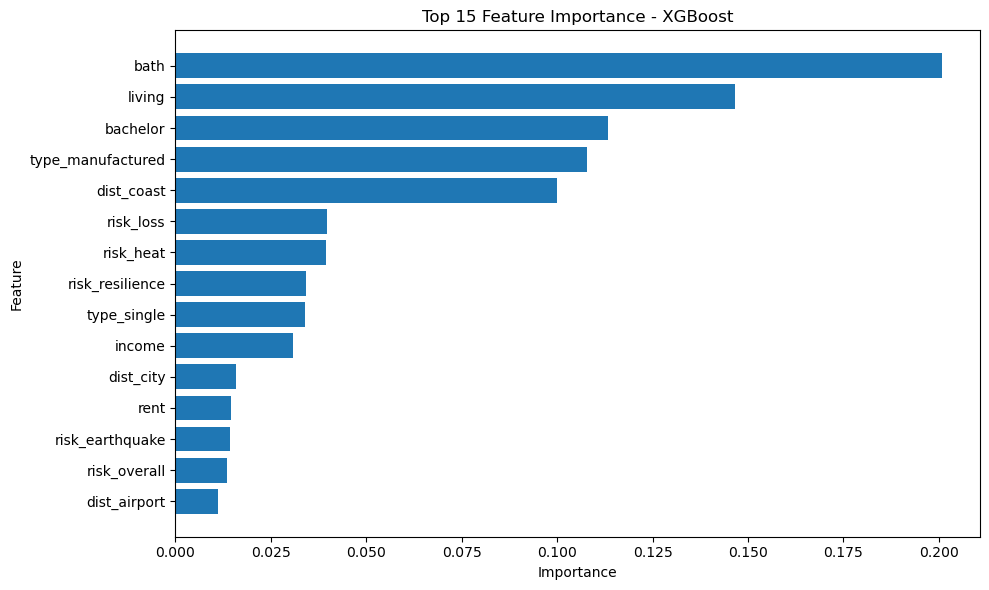

In [10]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()